Dataset Shape: (918, 12)

--- Linear Regression Evaluation ---
R2 Score: 0.1158
Mean Squared Error: 11459.87


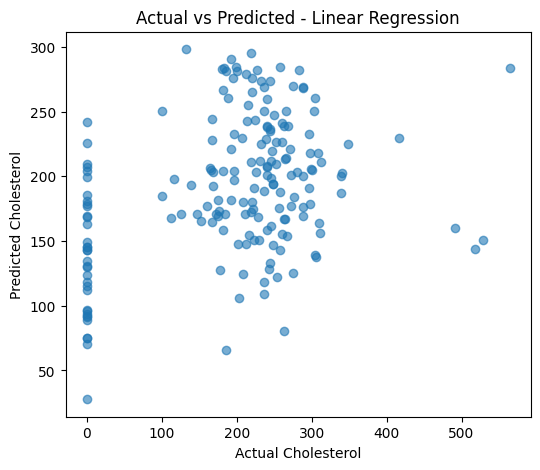


--- Model Evaluation ---
Accuracy Score: 85.33%

Confusion Matrix:
 [[67 10]
 [17 90]]

Classification Report:

              precision    recall  f1-score   support

           0       0.80      0.87      0.83        77
           1       0.90      0.84      0.87       107

    accuracy                           0.85       184
   macro avg       0.85      0.86      0.85       184
weighted avg       0.86      0.85      0.85       184



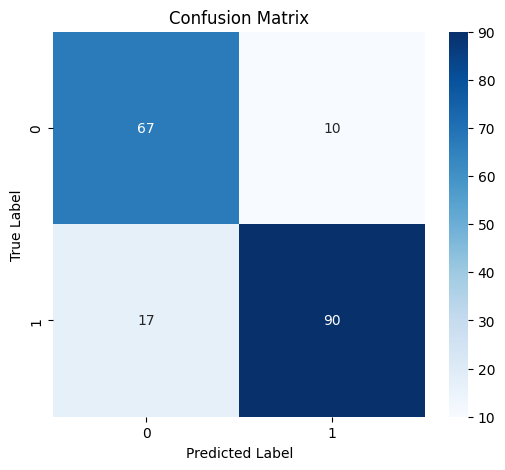


--- Final Tuned Model Evaluation ---
Accuracy Score: 85.33%
              precision    recall  f1-score   support

           0       0.80      0.87      0.83        77
           1       0.90      0.84      0.87       107

    accuracy                           0.85       184
   macro avg       0.85      0.86      0.85       184
weighted avg       0.86      0.85      0.85       184



In [3]:
# ==========================================
# EXPERIMENT 1
# Linear & Logistic Regression
# Dataset: Kaggle Heart Disease
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler

# ------------------------------------------
# 1. Load Dataset
# ------------------------------------------
df = pd.read_csv("heart.csv")
print("Dataset Shape:", df.shape)

# Convert categorical columns
df = pd.get_dummies(df, drop_first=True)

# ==========================================
# PART A: LINEAR REGRESSION
# Predict Cholesterol
# ==========================================

X_lin = df.drop("Cholesterol", axis=1)
y_lin = df["Cholesterol"]

X_train, X_test, y_train, y_test = train_test_split(
    X_lin, y_lin, test_size=0.2, random_state=42
)

lin_model = LinearRegression()
lin_model.fit(X_train, y_train)

y_pred_lin = lin_model.predict(X_test)

r2 = r2_score(y_test, y_pred_lin)
mse = mean_squared_error(y_test, y_pred_lin)

print("\n--- Linear Regression Evaluation ---")
print(f"R2 Score: {r2:.4f}")
print(f"Mean Squared Error: {mse:.2f}")

# Optional Regression Plot
plt.figure(figsize=(6,5))
plt.scatter(y_test, y_pred_lin, alpha=0.6)
plt.xlabel("Actual Cholesterol")
plt.ylabel("Predicted Cholesterol")
plt.title("Actual vs Predicted - Linear Regression")
plt.show()

# ==========================================
# PART B: LOGISTIC REGRESSION
# Predict HeartDisease
# ==========================================

X_log = df.drop("HeartDisease", axis=1)
y_log = df["HeartDisease"]

scaler = StandardScaler()
X_log = scaler.fit_transform(X_log)

X_train, X_test, y_train, y_test = train_test_split(
    X_log, y_log, test_size=0.2, random_state=42
)

log_model = LogisticRegression(max_iter=5000)
log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred_log)
cm = confusion_matrix(y_test, y_pred_log)

print("\n--- Model Evaluation ---")
print(f"Accuracy Score: {accuracy*100:.2f}%")
print("\nConfusion Matrix:\n", cm)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_log))

# Confusion Matrix Heatmap
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

print("\n--- Final Tuned Model Evaluation ---")
print(f"Accuracy Score: {accuracy*100:.2f}%")
print(classification_report(y_test, y_pred_log))